In [1]:
pip install tensorflow  


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

In [13]:
# Step 2: Load Dataset
df = pd.read_csv(r"C:\Users\Admin\Downloads\T251.csv")
print(df.head())


   TopDepth  BotDepth     _CAL      _GR      _SP     _LLD     _LLS       _AC  \
0   1446.00   1447.00  10.4456  109.729 -16.8322  7.42063  9.66313  112.4360   
1   1447.00   1448.25  10.8467  119.639 -16.6702  5.50612  6.30019  123.3030   
2   1448.25   1452.00  11.5728  107.947 -16.7381  3.68088  3.55019  114.4590   
3   1452.00   1456.00  10.4329  109.041 -16.8039  4.97871  4.84161  108.5620   
4   1456.00   1458.00  11.0826  108.398 -16.7764  3.47091  3.67475   98.5873   

      _DEN      _PEF Lith_Section  
0  2.14767  0.824501     mudstone  
1  2.05436  0.815773     mudstone  
2  2.02467  0.804632     mudstone  
3  2.10420  0.793730     mudstone  
4  2.10420  0.782799     mudstone  


In [14]:
# Step 3: Features & Target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [15]:
# Step 4: Handle Missing Values
X = X.fillna(X.mean())

In [16]:

# Step 5: Encode Target (VERY IMPORTANT)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [17]:
# Step 6: Scaling (optional but keeping same format)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:

# Step 7: Train XGBoost Model (FULL DATA)
xgb = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    objective='multi:softprob',   # Correct for multi-class
    eval_metric='mlogloss',
    random_state=42,
    tree_method='hist'   # faster (optional)
)

xgb.fit(X_scaled, y_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [19]:

# Step 8: Prediction
y_pred = xgb.predict(X_scaled)

In [20]:
# Step 9: Accuracy
print("XGBoost Accuracy (Full Data):", accuracy_score(y_encoded, y_pred))

XGBoost Accuracy (Full Data): 1.0


In [21]:
# Step 10: Classification Report
print("\nClassification Report:\n",
      classification_report(y_encoded, y_pred, target_names=le.classes_))


Classification Report:
                  precision    recall  f1-score   support

muddy siltstone       1.00      1.00      1.00        62
       mudstone       1.00      1.00      1.00       301
      oil shale       1.00      1.00      1.00         6
      siltstone       1.00      1.00      1.00       108
 silty mudstone       1.00      1.00      1.00       110

       accuracy                           1.00       587
      macro avg       1.00      1.00      1.00       587
   weighted avg       1.00      1.00      1.00       587



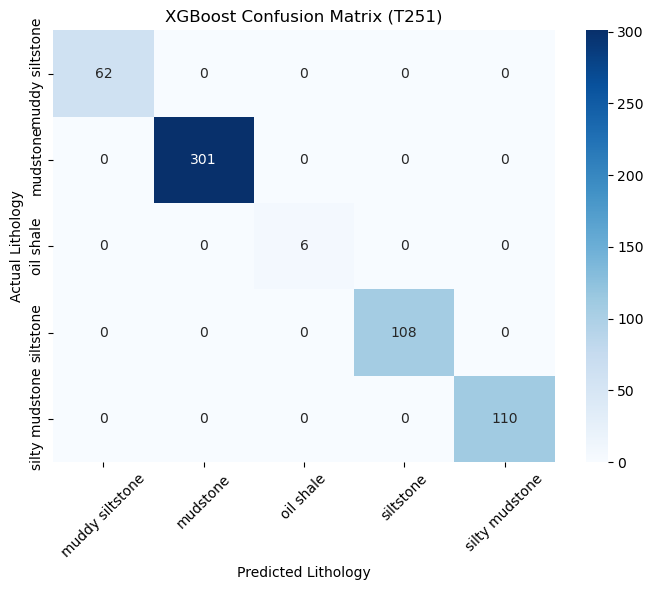

In [22]:
# Step 11: Confusion Matrix
cm = confusion_matrix(y_encoded, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("XGBoost Confusion Matrix (T251)")
plt.xlabel("Predicted Lithology")
plt.ylabel("Actual Lithology")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()